Dựa trên bài lab đã học tuần trước (CNN thuần), hãy thay data thành các tập dữ lieu khác như:
- Cat and dog
- CIFAR-10
- PlantVillage
    - Sử dung các phương pháp phân tích dữ lieu can bang dữ lieu
    - Cố gang thay đổi các tham số sao cho độ chính xác lớn hơn 90% và tránh trường hợp học vẹt
    - Không dung các mô hình retrain hoặc các mô hình như Resnet, Connextynit tiny

**Deadline 21/3/2026**

# Cat and Dog

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np


transform_train = transforms.Compose([
    transforms.Resize((132, 132)),
    transforms.RandomCrop(128),      
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])
transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])
train_dataset = ImageFolder(root='Cat_and_Dog/training_set',transform=transform_train)
test_dataset = ImageFolder(root='Cat_and_Dog/test_set',transform=transform_test) # Lưu ý: Đã sửa lại thành transform_test cho tập test

train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=64,shuffle=False)

In [ ]:
class CatDog_CNN(nn.Module):
    def __init__(self):
        super(CatDog_CNN, self).__init__()
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(32) 
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.conv4a = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4a = nn.BatchNorm2d(256)
        self.conv4b = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4b = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5) # Chống học vẹt
        self.fc2 = nn.Linear(512, 2)   # Đầu ra 2 lớp (Chó/Mèo)

    def forward(self, x):
        x = torch.relu(self.bn1a(self.conv1a(x)))
        x = self.pool1(torch.relu(self.bn1b(self.conv1b(x))))
        x = torch.relu(self.bn2a(self.conv2a(x)))
        x = self.pool2(torch.relu(self.bn2b(self.conv2b(x))))
        x = torch.relu(self.bn3a(self.conv3a(x)))
        x = self.pool3(torch.relu(self.bn3b(self.conv3b(x))))
        x = torch.relu(self.bn4a(self.conv4a(x)))
        x = self.pool4(torch.relu(self.bn4b(self.conv4b(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [67]:
# Khởi tạo mô hình
model = CatDog_CNN()  # Tạo một instance của lớp CatDog_CNN
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Chọn GPU nếu có, không thì dùng CPU
model.to(device)  # Chuyển mô hình sang thiết bị đã chọn (GPU/CPU)

loss_values = []  
accuracy_values = []  

for epoch in range(50):  
    model.train() 
    running_loss = 0.0  
    correct = 0  
    total = 0  
    for images, labels in train_loader:  
        images, labels = images.to(device), labels.to(device)  
        optimizer.zero_grad()  
        outputs = model(images)  
        loss = criterion(outputs, labels)  
        loss.backward()  
        optimizer.step()  
        
        running_loss += loss.item()  
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  
    
    epoch_loss = running_loss / len(train_loader)  
    epoch_accuracy = 100 * correct / total  
    loss_values.append(epoch_loss)  
    accuracy_values.append(epoch_accuracy)  
    scheduler.step()
    
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch 1, Loss: 1.1439, Accuracy: 52.11%
Epoch 2, Loss: 0.6606, Accuracy: 61.15%
Epoch 3, Loss: 0.6357, Accuracy: 63.95%
Epoch 4, Loss: 0.6156, Accuracy: 65.41%
Epoch 5, Loss: 0.5926, Accuracy: 68.60%
Epoch 6, Loss: 0.5848, Accuracy: 69.31%
Epoch 7, Loss: 0.5701, Accuracy: 70.29%
Epoch 8, Loss: 0.5562, Accuracy: 71.86%
Epoch 9, Loss: 0.5338, Accuracy: 73.40%
Epoch 10, Loss: 0.5274, Accuracy: 73.74%
Epoch 11, Loss: 0.4774, Accuracy: 77.41%
Epoch 12, Loss: 0.4340, Accuracy: 80.14%
Epoch 13, Loss: 0.4365, Accuracy: 80.35%
Epoch 14, Loss: 0.4061, Accuracy: 81.76%
Epoch 15, Loss: 0.3833, Accuracy: 83.39%
Epoch 16, Loss: 0.3612, Accuracy: 84.01%
Epoch 17, Loss: 0.3367, Accuracy: 85.66%
Epoch 18, Loss: 0.3026, Accuracy: 87.20%
Epoch 19, Loss: 0.2904, Accuracy: 88.06%
Epoch 20, Loss: 0.2671, Accuracy: 89.08%
Epoch 21, Loss: 0.2313, Accuracy: 90.79%
Epoch 22, Loss: 0.2095, Accuracy: 91.19%
Epoch 23, Loss: 0.2015, Accuracy: 92.14%
Epoch 24, Loss: 0.2005, Accuracy: 92.33%
Epoch 25, Loss: 0.1807, A

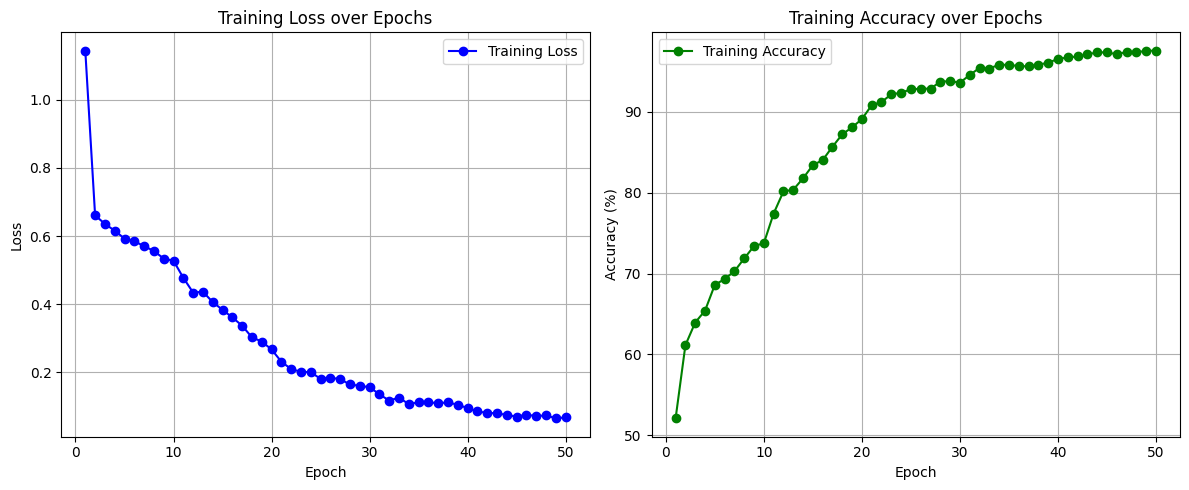

In [69]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 51), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 51), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [70]:
correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu
model.eval() 
with torch.no_grad():  # Tắt tính gradient vì chỉ đánh giá, không huấn luyện
    for images, labels in test_loader:  # Lặp qua từng batch trong tập kiểm tra
        images, labels = images.to(device), labels.to(device)  # Chuyển dữ liệu sang GPU/CPU
        outputs = model(images)  # Dự đoán trên batch ảnh
        _, predicted = torch.max(outputs.data, 1)  # Lấy chỉ số lớp có giá trị lớn nhất (dự đoán)
        total += labels.size(0)  # Cộng số mẫu trong batch vào tổng
        correct += (predicted == labels).sum().item()  # Cộng số dự đoán đúng
print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")  # Tính và in độ chính xác (%)

Độ chính xác trên tập test: 94.75%


# CIFAR-10

In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = ImageFolder(root='CIFAR-10/train', transform=transform_train)
test_dataset = ImageFolder(root='CIFAR-10/test', transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [116]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(32) 
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)      
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.bn1a(self.conv1a(x)))
        x = self.pool1(torch.relu(self.bn1b(self.conv1b(x))))
        x = torch.relu(self.bn2a(self.conv2a(x)))
        x = self.pool2(torch.relu(self.bn2b(self.conv2b(x))))
        x = torch.relu(self.bn3a(self.conv3a(x)))
        x = self.pool3(torch.relu(self.bn3b(self.conv3b(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [117]:
model = CIFAR10_CNN()  # Bắt buộc phải là CIFAR10_CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

In [118]:
# 3. Huấn luyện mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

loss_values = [] 
accuracy_values = []

for epoch in range(80):
    model.train() 
    running_loss = 0.0  
    correct = 0  
    total = 0  
    
    for images, labels in train_loader:  
        images, labels = images.to(device), labels.to(device)  
        
        optimizer.zero_grad()  
        outputs = model(images)  
        loss = criterion(outputs, labels)  
        loss.backward()  
        optimizer.step()  
        
        running_loss += loss.item()  
        
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  
    
    epoch_loss = running_loss / len(train_loader)  
    epoch_accuracy = 100 * correct / total  
    loss_values.append(epoch_loss)  
    accuracy_values.append(epoch_accuracy)  
    scheduler.step()
    
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch 1, Loss: 1.5163, Accuracy: 44.37%
Epoch 2, Loss: 1.1072, Accuracy: 60.80%
Epoch 3, Loss: 0.9342, Accuracy: 67.34%
Epoch 4, Loss: 0.8212, Accuracy: 71.61%
Epoch 5, Loss: 0.7384, Accuracy: 74.73%
Epoch 6, Loss: 0.6707, Accuracy: 77.35%
Epoch 7, Loss: 0.6271, Accuracy: 78.73%
Epoch 8, Loss: 0.5823, Accuracy: 80.50%
Epoch 9, Loss: 0.5475, Accuracy: 81.48%
Epoch 10, Loss: 0.5175, Accuracy: 82.91%
Epoch 11, Loss: 0.4878, Accuracy: 83.63%
Epoch 12, Loss: 0.4653, Accuracy: 84.61%
Epoch 13, Loss: 0.4403, Accuracy: 85.23%
Epoch 14, Loss: 0.4233, Accuracy: 85.59%
Epoch 15, Loss: 0.4093, Accuracy: 86.25%
Epoch 16, Loss: 0.3363, Accuracy: 88.62%
Epoch 17, Loss: 0.3149, Accuracy: 89.26%
Epoch 18, Loss: 0.2996, Accuracy: 89.90%
Epoch 19, Loss: 0.2905, Accuracy: 90.09%
Epoch 20, Loss: 0.2818, Accuracy: 90.55%
Epoch 21, Loss: 0.2713, Accuracy: 90.60%
Epoch 22, Loss: 0.2656, Accuracy: 90.95%
Epoch 23, Loss: 0.2579, Accuracy: 91.22%
Epoch 24, Loss: 0.2530, Accuracy: 91.43%
Epoch 25, Loss: 0.2446, A

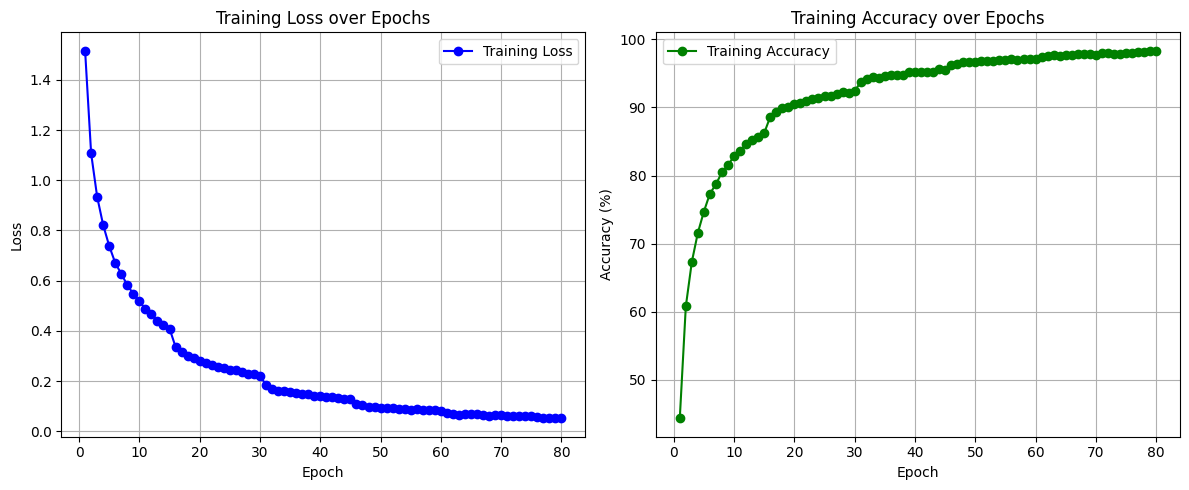

In [119]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 81), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 81), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [120]:
correct = 0  
total = 0  
model.eval()
with torch.no_grad():  
    for images, labels in test_loader:  
        images, labels = images.to(device), labels.to(device)  
        outputs = model(images)  
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")

Độ chính xác trên tập test: 90.27%


# PlantVillage

In [141]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
from torch.utils.data import DataLoader, Subset

transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

data_dir = 'PlantVillage/color'

# Load  ảnh làm 2 bản với 2 transform khác nhau
full_train_dataset = ImageFolder(root=data_dir, transform=transform_train)
full_test_dataset = ImageFolder(root=data_dir, transform=transform_test)
# Đảo lộn ngẫu nhiên và cắt 80% - 20%
num_samples = len(full_train_dataset)
indices = list(range(num_samples))
np.random.seed(42) # Cố định để lần sau chạy tập Test không bị đổi
np.random.shuffle(indices)

split = int(np.floor(0.2 * num_samples)) # Lấy 20% làm tập Test
train_idx, test_idx = indices[split:], indices[:split]
train_dataset = Subset(full_train_dataset, train_idx)
test_dataset = Subset(full_test_dataset, test_idx)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"Tổng số ảnh trong thư mục color: {num_samples}")
print(f"Đã chia vào tập Train: {len(train_dataset)} ảnh")
print(f"Đã chia vào tập Test: {len(test_dataset)} ảnh")

Tổng số ảnh trong thư mục color: 54305
Đã chia vào tập Train: 43444 ảnh
Đã chia vào tập Test: 10861 ảnh


In [142]:
class PlantVillage_CNN(nn.Module):
    def __init__(self, num_classes=38):
        super(PlantVillage_CNN, self).__init__()
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(32) 
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.conv4a = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4a = nn.BatchNorm2d(256)
        self.conv4b = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4b = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 8 * 8, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes) # Đầu ra 38 lớp

    def forward(self, x):
        x = torch.relu(self.bn1a(self.conv1a(x)))
        x = self.pool1(torch.relu(self.bn1b(self.conv1b(x))))       
        x = torch.relu(self.bn2a(self.conv2a(x)))
        x = self.pool2(torch.relu(self.bn2b(self.conv2b(x)))) 
        x = torch.relu(self.bn3a(self.conv3a(x)))
        x = self.pool3(torch.relu(self.bn3b(self.conv3b(x))))     
        x = torch.relu(self.bn4a(self.conv4a(x)))
        x = self.pool4(torch.relu(self.bn4b(self.conv4b(x))))      
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [143]:
model = PlantVillage_CNN(num_classes=38).to(device) 

criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

In [144]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

loss_values = [] 
accuracy_values = []

for epoch in range(30):  
    model.train()
    running_loss = 0.0  
    correct = 0  
    total = 0  
    for images, labels in train_loader:  
        images, labels = images.to(device), labels.to(device)  
        optimizer.zero_grad()  
        outputs = model(images)  
        loss = criterion(outputs, labels)  
        loss.backward()  
        optimizer.step()  
        running_loss += loss.item()  
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  
        
    epoch_loss = running_loss / len(train_loader)  
    epoch_accuracy = 100 * correct / total  
    loss_values.append(epoch_loss)
    accuracy_values.append(epoch_accuracy)
    scheduler.step()
    
    print(f"Epoch {epoch+1:02d}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

Epoch 01, Loss: 2.6950, Accuracy: 28.83%
Epoch 02, Loss: 1.8058, Accuracy: 47.17%
Epoch 03, Loss: 1.4364, Accuracy: 56.30%
Epoch 04, Loss: 1.1622, Accuracy: 64.14%
Epoch 05, Loss: 0.9365, Accuracy: 70.86%
Epoch 06, Loss: 0.7604, Accuracy: 76.24%
Epoch 07, Loss: 0.6342, Accuracy: 80.08%
Epoch 08, Loss: 0.5336, Accuracy: 83.18%
Epoch 09, Loss: 0.4421, Accuracy: 86.00%
Epoch 10, Loss: 0.3952, Accuracy: 87.65%
Epoch 11, Loss: 0.3382, Accuracy: 89.40%
Epoch 12, Loss: 0.2988, Accuracy: 90.60%
Epoch 13, Loss: 0.2676, Accuracy: 91.78%
Epoch 14, Loss: 0.2397, Accuracy: 92.58%
Epoch 15, Loss: 0.2196, Accuracy: 93.10%
Epoch 16, Loss: 0.1336, Accuracy: 95.85%
Epoch 17, Loss: 0.1160, Accuracy: 96.32%
Epoch 18, Loss: 0.1145, Accuracy: 96.37%
Epoch 19, Loss: 0.1048, Accuracy: 96.69%
Epoch 20, Loss: 0.1031, Accuracy: 96.76%
Epoch 21, Loss: 0.1021, Accuracy: 96.74%
Epoch 22, Loss: 0.0903, Accuracy: 97.18%
Epoch 23, Loss: 0.0921, Accuracy: 97.11%
Epoch 24, Loss: 0.0848, Accuracy: 97.24%
Epoch 25, Loss: 

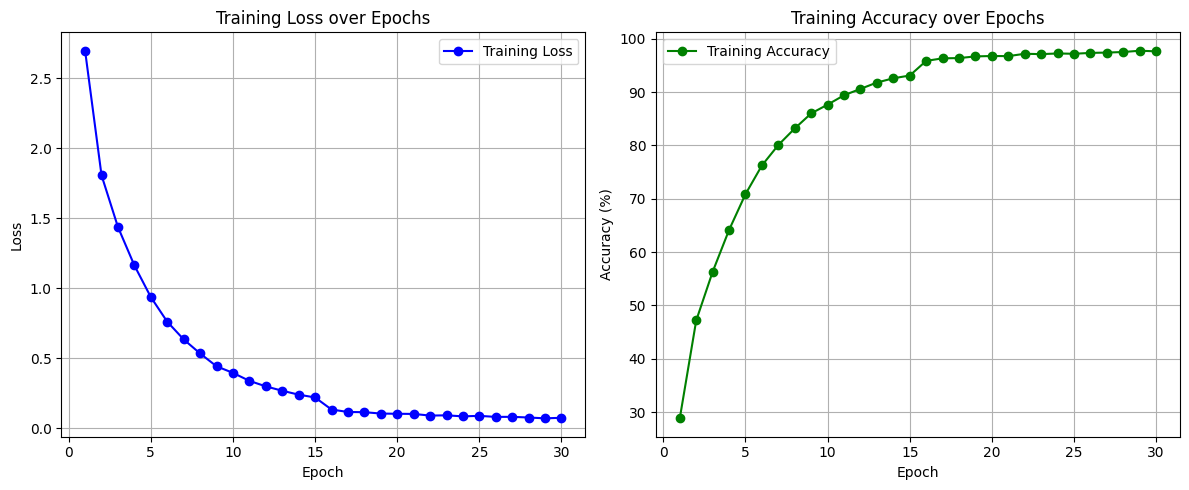

In [146]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 31), loss_values, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, 31), accuracy_values, marker='o', color='g', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [147]:
correct = 0  
total = 0  
model.eval() 
with torch.no_grad():  
    for images, labels in test_loader:  
        images, labels = images.to(device), labels.to(device)  
        outputs = model(images)  
        _, predicted = torch.max(outputs.data, 1)  
        total += labels.size(0)  
        correct += (predicted == labels).sum().item()  

print(f"Độ chính xác trên tập test PlantVillage: {100 * correct / total:.2f}%")

Độ chính xác trên tập test PlantVillage: 98.68%
